In [1]:
# Install maintained RL libraries for Google Colab
!pip -q install "gymnasium>=1.0,<2.0" "stable-baselines3>=2.4,<3.0" pandas numpy matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 4.2 MB/s eta 0:00:00


In [2]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
print('Gymnasium:', gym.__version__)

import matplotlib.pyplot as plt

Gymnasium: 1.3.0


In [3]:
# Upload your processed CSV file.
# Expected columns include: Crop, Annual_Rainfall, Yield, Modal_Price, Profit.
from google.colab import files

uploaded = files.upload()
if not uploaded:
    raise RuntimeError('No CSV file was uploaded.')

csv_files = [name for name in uploaded if name.lower().endswith('.csv')]
if not csv_files:
    raise ValueError('Please upload a .csv file.')

CSV_PATH = csv_files[0]
print('Using:', CSV_PATH)


Saving processed_data.csv to processed_data.csv
Using: processed_data.csv


In [4]:
REQUIRED_COLUMNS = ['Crop', 'Annual_Rainfall', 'Yield', 'Modal_Price', 'Profit']
OPTIONAL_NUMERIC_COLUMNS = ['Area', 'Production', 'Fertilizer', 'Pesticide', 'Revenue', 'Cost']

df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.strip()

missing = [column for column in REQUIRED_COLUMNS if column not in df.columns]
if missing:
    raise ValueError(
        f'Missing required columns: {missing}. Available columns: {df.columns.tolist()}'
    )

# Standardise crop names and numeric data.
df['Crop'] = df['Crop'].astype(str).str.strip()
df = df[df['Crop'].ne('') & df['Crop'].str.lower().ne('nan')].copy()

numeric_columns = list(dict.fromkeys(REQUIRED_COLUMNS[1:] + OPTIONAL_NUMERIC_COLUMNS))
for column in numeric_columns:
    if column in df.columns:
        df[column] = pd.to_numeric(df[column], errors='coerce')

# Fill required numeric gaps with crop medians, then global medians.
for column in REQUIRED_COLUMNS[1:]:
    df[column] = df.groupby('Crop')[column].transform(lambda s: s.fillna(s.median()))
    df[column] = df[column].fillna(df[column].median())

# Remove unusable rows and cap extreme values to make training more stable.
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=REQUIRED_COLUMNS).copy()
for column in REQUIRED_COLUMNS[1:]:
    low, high = df[column].quantile([0.01, 0.99])
    if np.isfinite(low) and np.isfinite(high) and low < high:
        df[column] = df[column].clip(low, high)

# Keep crops with enough examples for stochastic sampling.
counts = df['Crop'].value_counts()
valid_crops = counts[counts >= 2].index
if len(valid_crops) >= 2:
    df = df[df['Crop'].isin(valid_crops)].copy()

if df['Crop'].nunique() < 2:
    raise ValueError('The dataset must contain at least two different crops.')
if len(df) < 10:
    raise ValueError('The dataset needs at least 10 usable rows.')

df = df.reset_index(drop=True)
print('Rows:', len(df))
print('Crops:', df['Crop'].nunique())
print(df[REQUIRED_COLUMNS].head())


Rows: 3323
Crops: 6
     Crop  Annual_Rainfall     Yield  Modal_Price        Profit
0  Cotton           2051.4  0.420909  7018.952055  5.407008e+06
1   Maize           2051.4  0.615652  2600.000000  3.643986e+07
2   Onion           2051.4  2.342609  1464.607920  2.553166e+07
3  Potato           2051.4  7.561304   931.947187  6.189626e+08
4   Wheat           2051.4  1.259524  2462.426606  2.629129e+08


## Define and validate FarmEnv

In [5]:
class FarmEnv(gym.Env):
    """A crop-selection environment for long-term farmer income planning.

    Action:
        Select one crop from the discrete crop list.

    Observation (all float32 values scaled approximately to [-1, 1]):
        0. progress through the planning horizon
        1. current savings
        2. current rainfall condition
        3. current market-price condition
        4. current yield condition
        5. previously selected crop index (-1 when no previous crop)

    Reward:
        Realised crop profit, adjusted for rainfall and market uncertainty,
        minus crop-rotation and bankruptcy penalties. Reward is scaled for PPO.
    """

    metadata = {"render_modes": ["human"]}

    def __init__(
        self,
        data: pd.DataFrame,
        horizon_years: int = 20,
        initial_savings: float = 100_000.0,
        annual_living_cost: float | None = None,
        rainfall_volatility: float = 0.12,
        price_volatility: float = 0.10,
        rotation_penalty_rate: float = 0.20,
        reward_scale: float | None = None,
        render_mode: str | None = None,
    ):
        super().__init__()

        self.data = data.copy().reset_index(drop=True)
        required = {"Crop", "Annual_Rainfall", "Yield", "Modal_Price", "Profit"}
        missing = required.difference(self.data.columns)
        if missing:
            raise ValueError(f"FarmEnv missing columns: {sorted(missing)}")

        self.crops = sorted(self.data["Crop"].astype(str).unique().tolist())
        if len(self.crops) < 2:
            raise ValueError("FarmEnv requires at least two crops.")

        self.crop_to_index = {crop: i for i, crop in enumerate(self.crops)}
        self.crop_rows = {
            crop: self.data.index[self.data["Crop"] == crop].to_numpy()
            for crop in self.crops
        }

        self.horizon_years = int(horizon_years)
        self.initial_savings = float(initial_savings)
        self.rainfall_volatility = float(rainfall_volatility)
        self.price_volatility = float(price_volatility)
        self.rotation_penalty_rate = float(rotation_penalty_rate)
        self.render_mode = render_mode

        typical_profit = float(np.nanmedian(np.abs(self.data["Profit"].to_numpy())))
        self.profit_scale = max(typical_profit, 1.0)
        self.reward_scale = float(reward_scale or self.profit_scale)
        self.annual_living_cost = float(
            annual_living_cost if annual_living_cost is not None else 0.15 * self.profit_scale
        )
        self.savings_scale = max(
            abs(self.initial_savings) + self.horizon_years * self.profit_scale,
            1.0,
        )

        self.rain_min, self.rain_max = self._safe_bounds("Annual_Rainfall")
        self.price_min, self.price_max = self._safe_bounds("Modal_Price")
        self.yield_min, self.yield_max = self._safe_bounds("Yield")

        self.action_space = spaces.Discrete(len(self.crops))
        self.observation_space = spaces.Box(
            low=np.full(6, -1.0, dtype=np.float32),
            high=np.full(6, 1.0, dtype=np.float32),
            dtype=np.float32,
        )

        self.current_year = 0
        self.savings = self.initial_savings
        self.last_crop_index = -1
        self.current_context = None
        self.history = []

    def _safe_bounds(self, column: str) -> tuple[float, float]:
        values = self.data[column].astype(float).to_numpy()
        low, high = float(np.nanmin(values)), float(np.nanmax(values))
        if not np.isfinite(low) or not np.isfinite(high):
            return 0.0, 1.0
        if np.isclose(low, high):
            high = low + 1.0
        return low, high

    @staticmethod
    def _scale(value: float, low: float, high: float) -> float:
        scaled = 2.0 * (float(value) - low) / (high - low) - 1.0
        return float(np.clip(scaled, -1.0, 1.0))

    def _sample_context(self) -> dict:
        row = self.data.iloc[int(self.np_random.integers(0, len(self.data)))]
        return {
            "rainfall": float(row["Annual_Rainfall"]),
            "price": float(row["Modal_Price"]),
            "yield": float(row["Yield"]),
        }

    def _get_observation(self) -> np.ndarray:
        context = self.current_context
        progress = 2.0 * (self.current_year / max(self.horizon_years, 1)) - 1.0
        savings_scaled = np.clip(self.savings / self.savings_scale, -1.0, 1.0)
        last_crop_scaled = (
            -1.0
            if self.last_crop_index < 0
            else self._scale(self.last_crop_index, 0, max(len(self.crops) - 1, 1))
        )
        return np.array(
            [
                progress,
                savings_scaled,
                self._scale(context["rainfall"], self.rain_min, self.rain_max),
                self._scale(context["price"], self.price_min, self.price_max),
                self._scale(context["yield"], self.yield_min, self.yield_max),
                last_crop_scaled,
            ],
            dtype=np.float32,
        )

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self.current_year = 0
        self.savings = self.initial_savings
        self.last_crop_index = -1
        self.current_context = self._sample_context()
        self.history = []
        observation = self._get_observation()
        info = {
            "year": self.current_year,
            "savings": self.savings,
            "crops": self.crops,
        }
        return observation, info

    def step(self, action):
        action = int(action)
        if not self.action_space.contains(action):
            raise ValueError(f"Invalid action {action}; expected 0-{len(self.crops)-1}.")

        crop = self.crops[action]
        candidate_indices = self.crop_rows[crop]
        row_index = int(self.np_random.choice(candidate_indices))
        row = self.data.iloc[row_index]

        base_profit = float(row["Profit"])
        crop_rainfall = max(float(row["Annual_Rainfall"]), 1e-6)
        crop_price = max(float(row["Modal_Price"]), 1e-6)

        # Stochastic weather and market factors around the observed context.
        rain_noise = float(self.np_random.normal(1.0, self.rainfall_volatility))
        price_noise = float(self.np_random.normal(1.0, self.price_volatility))
        rainfall_ratio = (self.current_context["rainfall"] * rain_noise) / crop_rainfall
        price_ratio = (self.current_context["price"] * price_noise) / crop_price

        # Moderate response: very poor conditions hurt profit, while extreme gains are capped.
        climate_factor = float(np.clip(0.5 + 0.5 * rainfall_ratio, 0.35, 1.35))
        market_factor = float(np.clip(price_ratio, 0.50, 1.50))
        realised_profit = base_profit * climate_factor * market_factor

        rotation_penalty = 0.0
        if action == self.last_crop_index:
            rotation_penalty = abs(realised_profit) * self.rotation_penalty_rate

        net_income = realised_profit - rotation_penalty - self.annual_living_cost
        self.savings += net_income
        self.current_year += 1

        bankruptcy_penalty = 0.0
        terminated = self.savings <= 0.0
        if terminated:
            bankruptcy_penalty = self.profit_scale

        truncated = self.current_year >= self.horizon_years
        reward = (net_income - bankruptcy_penalty) / self.reward_scale

        record = {
            "year": self.current_year,
            "crop": crop,
            "base_profit": base_profit,
            "realised_profit": realised_profit,
            "rotation_penalty": rotation_penalty,
            "living_cost": self.annual_living_cost,
            "net_income": net_income,
            "savings": self.savings,
            "reward": reward,
        }
        self.history.append(record)
        self.last_crop_index = action

        if not (terminated or truncated):
            self.current_context = self._sample_context()

        observation = self._get_observation()
        info = record.copy()

        if self.render_mode == "human":
            self.render()

        return observation, float(reward), bool(terminated), bool(truncated), info

    def render(self):
        if not self.history:
            print(f"Year 0 | Savings: {self.savings:,.2f}")
            return
        last = self.history[-1]
        print(
            f"Year {last['year']:02d} | Crop: {last['crop']:<15} "
            f"| Net income: {last['net_income']:>12,.2f} "
            f"| Savings: {last['savings']:>12,.2f}"
        )

    def get_history(self) -> pd.DataFrame:
        return pd.DataFrame(self.history)


In [6]:
from stable_baselines3.common.env_checker import check_env

check_env(FarmEnv(df), warn=True)
print('✅ Environment is valid.')


✅ Environment is valid.


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Configure PPO training

In [7]:
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback, StopTrainingOnNoModelImprovement
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.utils import set_random_seed

TOTAL_TIMESTEPS = 30_000       # Increase to 100_000+ for final experiments
HORIZON_YEARS = 20
INITIAL_SAVINGS = 100_000.0
N_STEPS = 512
BATCH_SIZE = 64

set_random_seed(SEED)
Path('models').mkdir(exist_ok=True)
Path('logs').mkdir(exist_ok=True)
Path('results').mkdir(exist_ok=True)


def make_env(seed_offset=0):
    def _init():
        env = FarmEnv(
            df,
            horizon_years=HORIZON_YEARS,
            initial_savings=INITIAL_SAVINGS,
        )
        env = Monitor(env)
        env.reset(seed=SEED + seed_offset)
        return env
    return _init

train_env = DummyVecEnv([make_env(0)])
train_env = VecNormalize(train_env, norm_obs=True, norm_reward=True, clip_obs=10.0)

eval_env = DummyVecEnv([make_env(1000)])
eval_env = VecNormalize(eval_env, norm_obs=True, norm_reward=False, training=False, clip_obs=10.0)

print('Training crops:', len(df['Crop'].unique()))
print('Training timesteps:', TOTAL_TIMESTEPS)


Training crops: 6
Training timesteps: 30000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Train the PPO agent

In [8]:
class RewardHistoryCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.timesteps = []
        self.episode_rewards = []

    def _on_step(self) -> bool:
        for info in self.locals.get('infos', []):
            if 'episode' in info:
                self.timesteps.append(self.num_timesteps)
                self.episode_rewards.append(float(info['episode']['r']))
        return True

reward_callback = RewardHistoryCallback()
stop_callback = StopTrainingOnNoModelImprovement(
    max_no_improvement_evals=8,
    min_evals=5,
    verbose=1,
)
eval_callback = EvalCallback(
    eval_env,
    best_model_save_path='models/best',
    log_path='logs/eval',
    eval_freq=2_500,
    n_eval_episodes=10,
    deterministic=True,
    callback_after_eval=stop_callback,
    verbose=1,
)

model = PPO(
    policy='MlpPolicy',
    env=train_env,
    learning_rate=3e-4,
    n_steps=N_STEPS,
    batch_size=BATCH_SIZE,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    vf_coef=0.5,
    max_grad_norm=0.5,
    seed=SEED,
    verbose=1,
    tensorboard_log='logs/tensorboard',
)

model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=[reward_callback, eval_callback],
    progress_bar=True,
)

model.save('models/ppo_farmer_model')
train_env.save('models/vec_normalize.pkl')
print('✅ Model and normalisation statistics saved.')


Using cpu device
Logging to logs/tensorboard/PPO_1


Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 11.9     |
|    ep_rew_mean     | 254      |
| time/              |          |
|    fps             | 406      |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 512      |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 12          |
|    ep_rew_mean          | 239         |
| time/                   |             |
|    fps                  | 342         |
|    iterations           | 2           |
|    time_elapsed         | 2           |
|    total_timesteps      | 1024        |
| train/                  |             |
|    approx_kl            | 0.004667096 |
|    clip_fraction        | 0.0082      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.79       |
|    explained_variance   | -0.09       |
|    learning_rate        | 0.

...

------------------------------------------
| eval/                   |              |
|    mean_ep_length       | 16.2         |
|    mean_reward          | 674          |
| time/                   |              |
|    total_timesteps      | 27500        |
| train/                  |              |
|    approx_kl            | 0.0037678587 |
|    clip_fraction        | 0.0398       |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.275       |
|    explained_variance   | 0.35         |
|    learning_rate        | 0.0003       |
|    loss                 | 0.13         |
|    n_updates            | 530          |
|    policy_gradient_loss | -0.00824     |
|    value_loss           | 0.383        |
------------------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 17.9     |
|    ep_rew_mean     | 630      |
| time/              |          |
|    fps             | 363      |
|    iterations      |

Eval num_timesteps=30000, episode_reward=433.89 +/- 467.06

Episode length: 12.40 +/- 9.31

------------------------------------------
| eval/                   |              |
|    mean_ep_length       | 12.4         |
|    mean_reward          | 434          |
| time/                   |              |
|    total_timesteps      | 30000        |
| train/                  |              |
|    approx_kl            | 0.0022501224 |
|    clip_fraction        | 0.025        |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.289       |
|    explained_variance   | 0.349        |
|    learning_rate        | 0.0003       |
|    loss                 | 0.353        |
|    n_updates            | 580          |
|    policy_gradient_loss | -0.00595     |
|    value_loss           | 0.8          |
------------------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 17.3     |
|    ep_rew_mean     | 637      |
| time/              |          |
|    fps             | 353      |
|    iterations      |

✅ Model and normalisation statistics saved.


## Plot training rewards

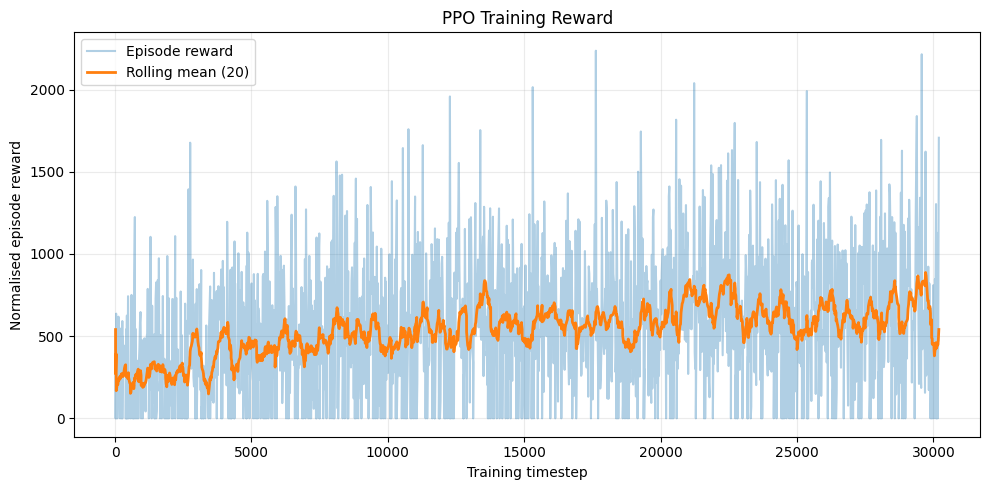

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [9]:
if reward_callback.episode_rewards:
    reward_df = pd.DataFrame({
        'timestep': reward_callback.timesteps,
        'episode_reward': reward_callback.episode_rewards,
    })
    reward_df['rolling_mean_20'] = reward_df['episode_reward'].rolling(20, min_periods=1).mean()
    reward_df.to_csv('results/training_rewards.csv', index=False)

    plt.figure(figsize=(10, 5))
    plt.plot(reward_df['timestep'], reward_df['episode_reward'], alpha=0.35, label='Episode reward')
    plt.plot(reward_df['timestep'], reward_df['rolling_mean_20'], linewidth=2, label='Rolling mean (20)')
    plt.xlabel('Training timestep')
    plt.ylabel('Normalised episode reward')
    plt.title('PPO Training Reward')
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig('results/training_reward.png', dpi=160)
    plt.show()
else:
    print('No completed episode rewards were recorded.')


## Evaluate the trained policy in the original environment

In [12]:
# ============================================================
# CORRECTED PPO EVALUATION CELL
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

# Use the best checkpoint if available.
best_path = Path("models/best/best_model.zip")

if best_path.exists():
    evaluation_model = PPO.load(best_path)
    print("Evaluating best checkpoint.")
else:
    evaluation_model = PPO.load("models/ppo_farmer_model")
    print("Evaluating final checkpoint.")

# Create a fresh evaluation environment.
raw_eval_vec = DummyVecEnv([make_env(2000)])

# Load the saved observation normalisation.
norm_eval_vec = VecNormalize.load(
    "models/vec_normalize.pkl",
    raw_eval_vec
)

# Disable training and reward normalisation during evaluation.
norm_eval_vec.training = False
norm_eval_vec.norm_reward = False

N_EVAL_EPISODES = 20

episode_summaries = []
all_years = []

for episode in range(1, N_EVAL_EPISODES + 1):

    obs = norm_eval_vec.reset()
    done = np.array([False])

    episode_reward = 0.0
    episode_history = []

    while not bool(done[0]):

        # PPO selects the best action.
        action, _ = evaluation_model.predict(
            obs,
            deterministic=True
        )

        obs, reward, done, infos = norm_eval_vec.step(action)

        episode_reward += float(reward[0])

        # Save the information returned directly by FarmEnv.step().
        step_info = infos[0]

        if "savings" in step_info:

            episode_history.append({
                "year": int(step_info.get(
                    "year",
                    len(episode_history) + 1
                )),
                "crop": step_info.get("crop", "Unknown"),
                "base_profit": float(
                    step_info.get("base_profit", 0.0)
                ),
                "realised_profit": float(
                    step_info.get("realised_profit", 0.0)
                ),
                "rotation_penalty": float(
                    step_info.get("rotation_penalty", 0.0)
                ),
                "living_cost": float(
                    step_info.get("living_cost", 0.0)
                ),
                "net_income": float(
                    step_info.get("net_income", 0.0)
                ),
                "savings": float(
                    step_info.get("savings", 0.0)
                ),
                "reward": float(reward[0]),
                "episode": episode
            })

    # Convert this episode's records to a DataFrame.
    history = pd.DataFrame(episode_history)

    if history.empty:
        print(
            f"Warning: Episode {episode} produced no history."
        )
        continue

    all_years.append(history)

    final_savings = float(
        history["savings"].iloc[-1]
    )

    episode_summaries.append({
        "episode": episode,
        "total_reward": episode_reward,
        "final_savings": final_savings,
        "total_net_income": float(
            history["net_income"].sum()
        ),
        "years_survived": int(len(history)),
        "bankrupt": bool(final_savings <= 0)
    })

# Create evaluation result tables.
evaluation_df = pd.DataFrame(episode_summaries)

if all_years:
    yearly_df = pd.concat(
        all_years,
        ignore_index=True
    )
else:
    yearly_df = pd.DataFrame()

# Create the results folder if it does not exist.
Path("results").mkdir(
    parents=True,
    exist_ok=True
)

# Save results.
evaluation_df.to_csv(
    "results/ppo_evaluation_summary.csv",
    index=False
)

yearly_df.to_csv(
    "results/ppo_yearly_decisions.csv",
    index=False
)

# Display results.
display(evaluation_df)

if not evaluation_df.empty:

    print(
        "\nAverage final savings:",
        evaluation_df["final_savings"].mean()
    )

    print(
        "Average total net income:",
        evaluation_df["total_net_income"].mean()
    )

    print(
        "Average years survived:",
        evaluation_df["years_survived"].mean()
    )

    print(
        "Bankruptcy rate:",
        evaluation_df["bankrupt"].mean()
    )

else:
    print("No valid evaluation episodes were recorded.")

Evaluating best checkpoint.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,episode,total_reward,final_savings,total_net_income,years_survived,bankrupt
0,1,855.252594,1.422066e+11,1.422065e+11,20,False
1,2,1473.570038,2.450169e+11,2.450168e+11,20,False
2,3,166.036688,2.760774e+10,2.760764e+10,20,False
3,4,317.275973,5.275494e+10,5.275484e+10,20,False
4,5,787.916900,1.310104e+11,1.310103e+11,20,False
5,6,799.305355,1.329040e+11,1.329039e+11,20,False
6,7,-1.108495,-1.793988e+07,-1.803988e+07,1,True
7,8,675.946102,1.123926e+11,1.123925e+11,20,False
8,9,714.385620,1.187841e+11,1.187840e+11,20,False
9,10,811.341189,1.349053e+11,1.349052e+11,20,False



Average final savings: 106749884867.08028
Average total net income: 106749784867.08026
Average years survived: 18.1
Bankruptcy rate: 0.1


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Compare PPO against a random baseline

,average_reward,average_final_savings,average_net_income,average_years_survived
strategy,,,,
PPO,641.91,1.067499e+11,1.067498e+11,18.1
Random,277.23,4.613843e+10,4.613833e+10,15.4


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


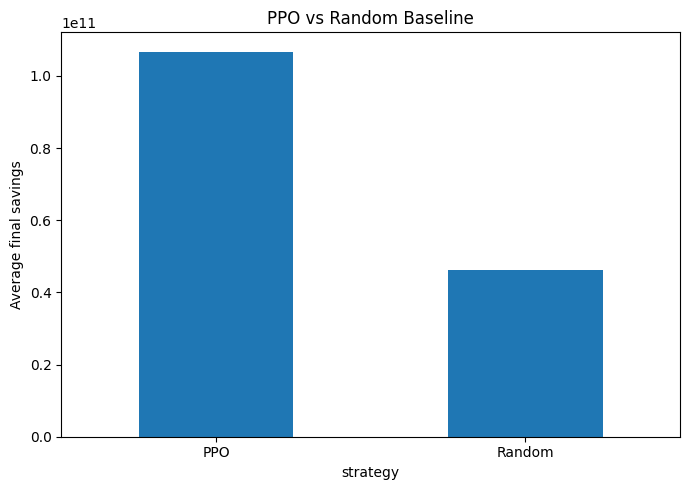

In [13]:
def evaluate_random_policy(n_episodes=20, seed=5000):
    summaries = []
    rng = np.random.default_rng(seed)
    for episode in range(1, n_episodes + 1):
        env = FarmEnv(df, horizon_years=HORIZON_YEARS, initial_savings=INITIAL_SAVINGS)
        obs, info = env.reset(seed=seed + episode)
        done = False
        total_reward = 0.0
        while not done:
            action = int(rng.integers(env.action_space.n))
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            done = terminated or truncated
        history = env.get_history()
        summaries.append({
            'episode': episode,
            'strategy': 'Random',
            'total_reward': total_reward,
            'final_savings': float(history['savings'].iloc[-1]),
            'total_net_income': float(history['net_income'].sum()),
            'years_survived': int(len(history)),
        })
    return pd.DataFrame(summaries)

random_df = evaluate_random_policy(N_EVAL_EPISODES)
ppo_compare = evaluation_df.assign(strategy='PPO')[
    ['episode', 'strategy', 'total_reward', 'final_savings', 'total_net_income', 'years_survived']
]
comparison_df = pd.concat([ppo_compare, random_df], ignore_index=True)
comparison_df.to_csv('results/ppo_vs_random.csv', index=False)

summary = comparison_df.groupby('strategy').agg(
    average_reward=('total_reward', 'mean'),
    average_final_savings=('final_savings', 'mean'),
    average_net_income=('total_net_income', 'mean'),
    average_years_survived=('years_survived', 'mean'),
).round(2)
display(summary)

plt.figure(figsize=(7, 5))
summary['average_final_savings'].plot(kind='bar')
plt.ylabel('Average final savings')
plt.title('PPO vs Random Baseline')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('results/ppo_vs_random.png', dpi=160)
plt.show()


## Crop-selection and savings plots

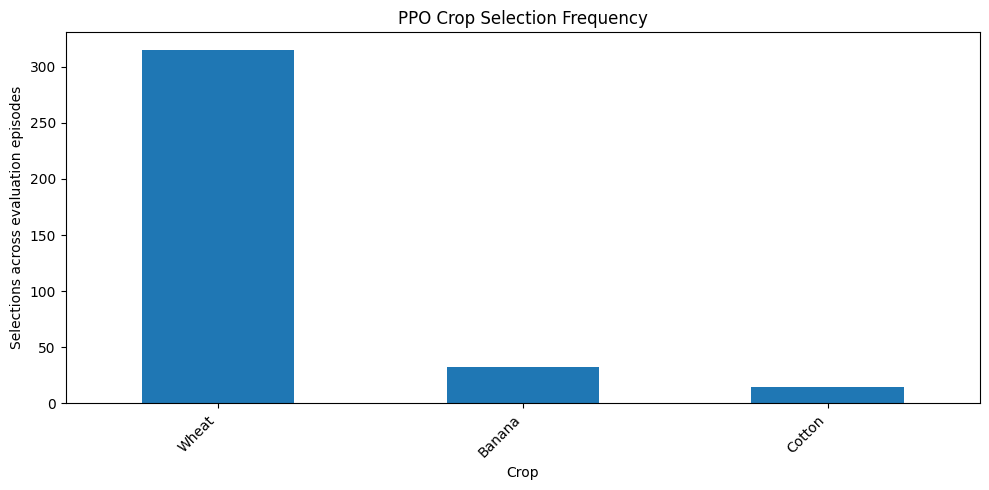

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


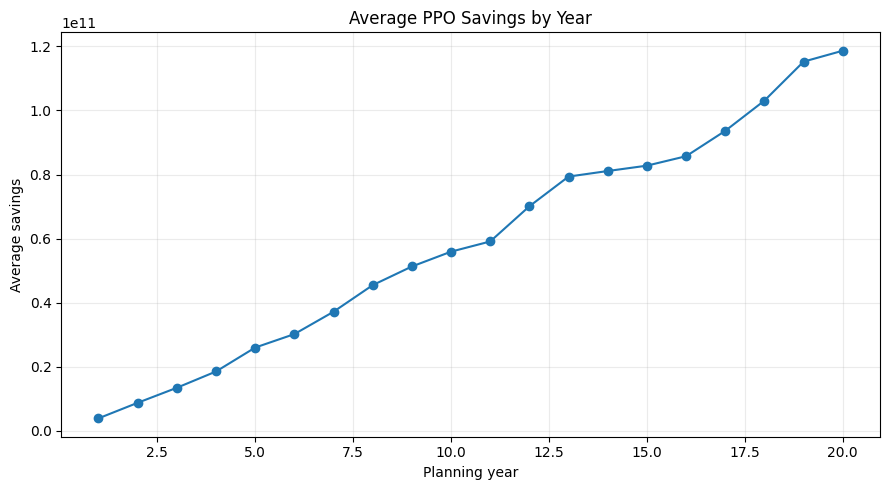

In [14]:
crop_counts = yearly_df['crop'].value_counts().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
crop_counts.plot(kind='bar')
plt.xlabel('Crop')
plt.ylabel('Selections across evaluation episodes')
plt.title('PPO Crop Selection Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('results/crop_selection_frequency.png', dpi=160)
plt.show()

mean_savings = yearly_df.groupby('year')['savings'].mean()
plt.figure(figsize=(9, 5))
plt.plot(mean_savings.index, mean_savings.values, marker='o')
plt.xlabel('Planning year')
plt.ylabel('Average savings')
plt.title('Average PPO Savings by Year')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig('results/average_savings_by_year.png', dpi=160)
plt.show()


## Package and download all outputs

In [15]:
import shutil
from google.colab import files

# Save crop mapping and configuration for reproducibility.
config = {
    'seed': SEED,
    'total_timesteps': TOTAL_TIMESTEPS,
    'horizon_years': HORIZON_YEARS,
    'initial_savings': INITIAL_SAVINGS,
    'crops': sorted(df['Crop'].unique().tolist()),
    'required_columns': REQUIRED_COLUMNS,
}
Path('results/training_config.json').write_text(json.dumps(config, indent=2), encoding='utf-8')

archive_path = shutil.make_archive(
    'Farmer_RL_Phase4_Outputs',
    'zip',
    root_dir='.',
    base_dir='models',
)

# Add results and logs to a complete package.
import zipfile
with zipfile.ZipFile('Farmer_RL_Phase4_Complete.zip', 'w', zipfile.ZIP_DEFLATED) as zf:
    for folder in ['models', 'results']:
        for path in Path(folder).rglob('*'):
            if path.is_file():
                zf.write(path, path.as_posix())

print('Created Farmer_RL_Phase4_Complete.zip')
files.download('Farmer_RL_Phase4_Complete.zip')


Created Farmer_RL_Phase4_Complete.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>